In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

!pip install catboost
# Installation de y-data-profiling (successeur de pandas-profiling)
!pip install ydata-profiling

# Ou pour une version plus ancienne (pandas-profiling)
!pip install pandas-profiling

# Preprocessing & feature selection
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif, RFE

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
sns.set_style('whitegrid')
%matplotlib inline
# if using notebook, otherwise use plt.show()

  Using cached visions-0.8.1-py3-none-any.whl.metadata (11 kB)
Using cached visions-0.8.1-py3-none-any.whl (105 kB)
  Attempting uninstall: visions
    Found existing installation: visions 0.7.4
    Uninstalling visions-0.7.4:
      Successfully uninstalled visions-0.7.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas-profiling 3.2.0 requires visions[type_image_path]==0.7.4, but you have visions 0.8.1 which is incompatible.
  Using cached visions-0.7.4-py3-none-any.whl.metadata (5.9 kB)
Using cached visions-0.7.4-py3-none-any.whl (102 kB)
  Attempting uninstall: visions
    Found existing installation: visions 0.8.1
    Uninstalling visions-0.8.1:
      Successfully uninstalled visions-0.8.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency c

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Ml/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Dataset shape
print(f"Dataset shape: {df.shape}")

df.info()

Dataset shape: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
import warnings
warnings.filterwarnings('ignore')

!pip install --upgrade ydata-profiling
from ydata_profiling   import ProfileReport

profile = ProfileReport(df, title="Profiling Report")
profile

  Using cached visions-0.8.1-py3-none-any.whl.metadata (11 kB)
Using cached visions-0.8.1-py3-none-any.whl (105 kB)
  Attempting uninstall: visions
    Found existing installation: visions 0.7.4
    Uninstalling visions-0.7.4:
      Successfully uninstalled visions-0.7.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas-profiling 3.2.0 requires visions[type_image_path]==0.7.4, but you have visions 0.8.1 which is incompatible.


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 21/21 [00:01<00:00, 17.89it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


# Data Cleaning


In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df['TotalCharges'].fillna(0, inplace=True)

df.drop('customerID', axis=1, inplace=True)

assert df.isnull().sum().sum() == 0, "There are still missing values!"

# Dataset is imbalanced ?

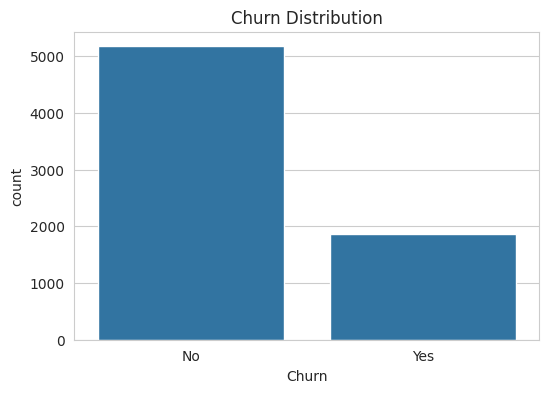

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

print(df['Churn'].value_counts(normalize=True))

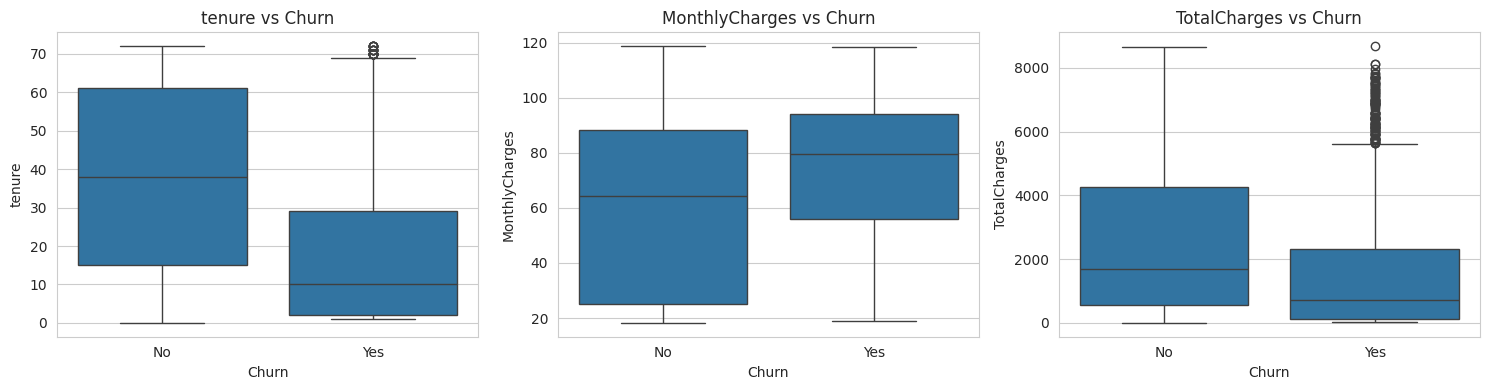

In [ ]:
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15,4))
for i, col in enumerate(numerical_features):
    sns.boxplot(x='Churn', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{col} vs Churn')
plt.tight_layout()
plt.show()

Categorical Features vs. Churn

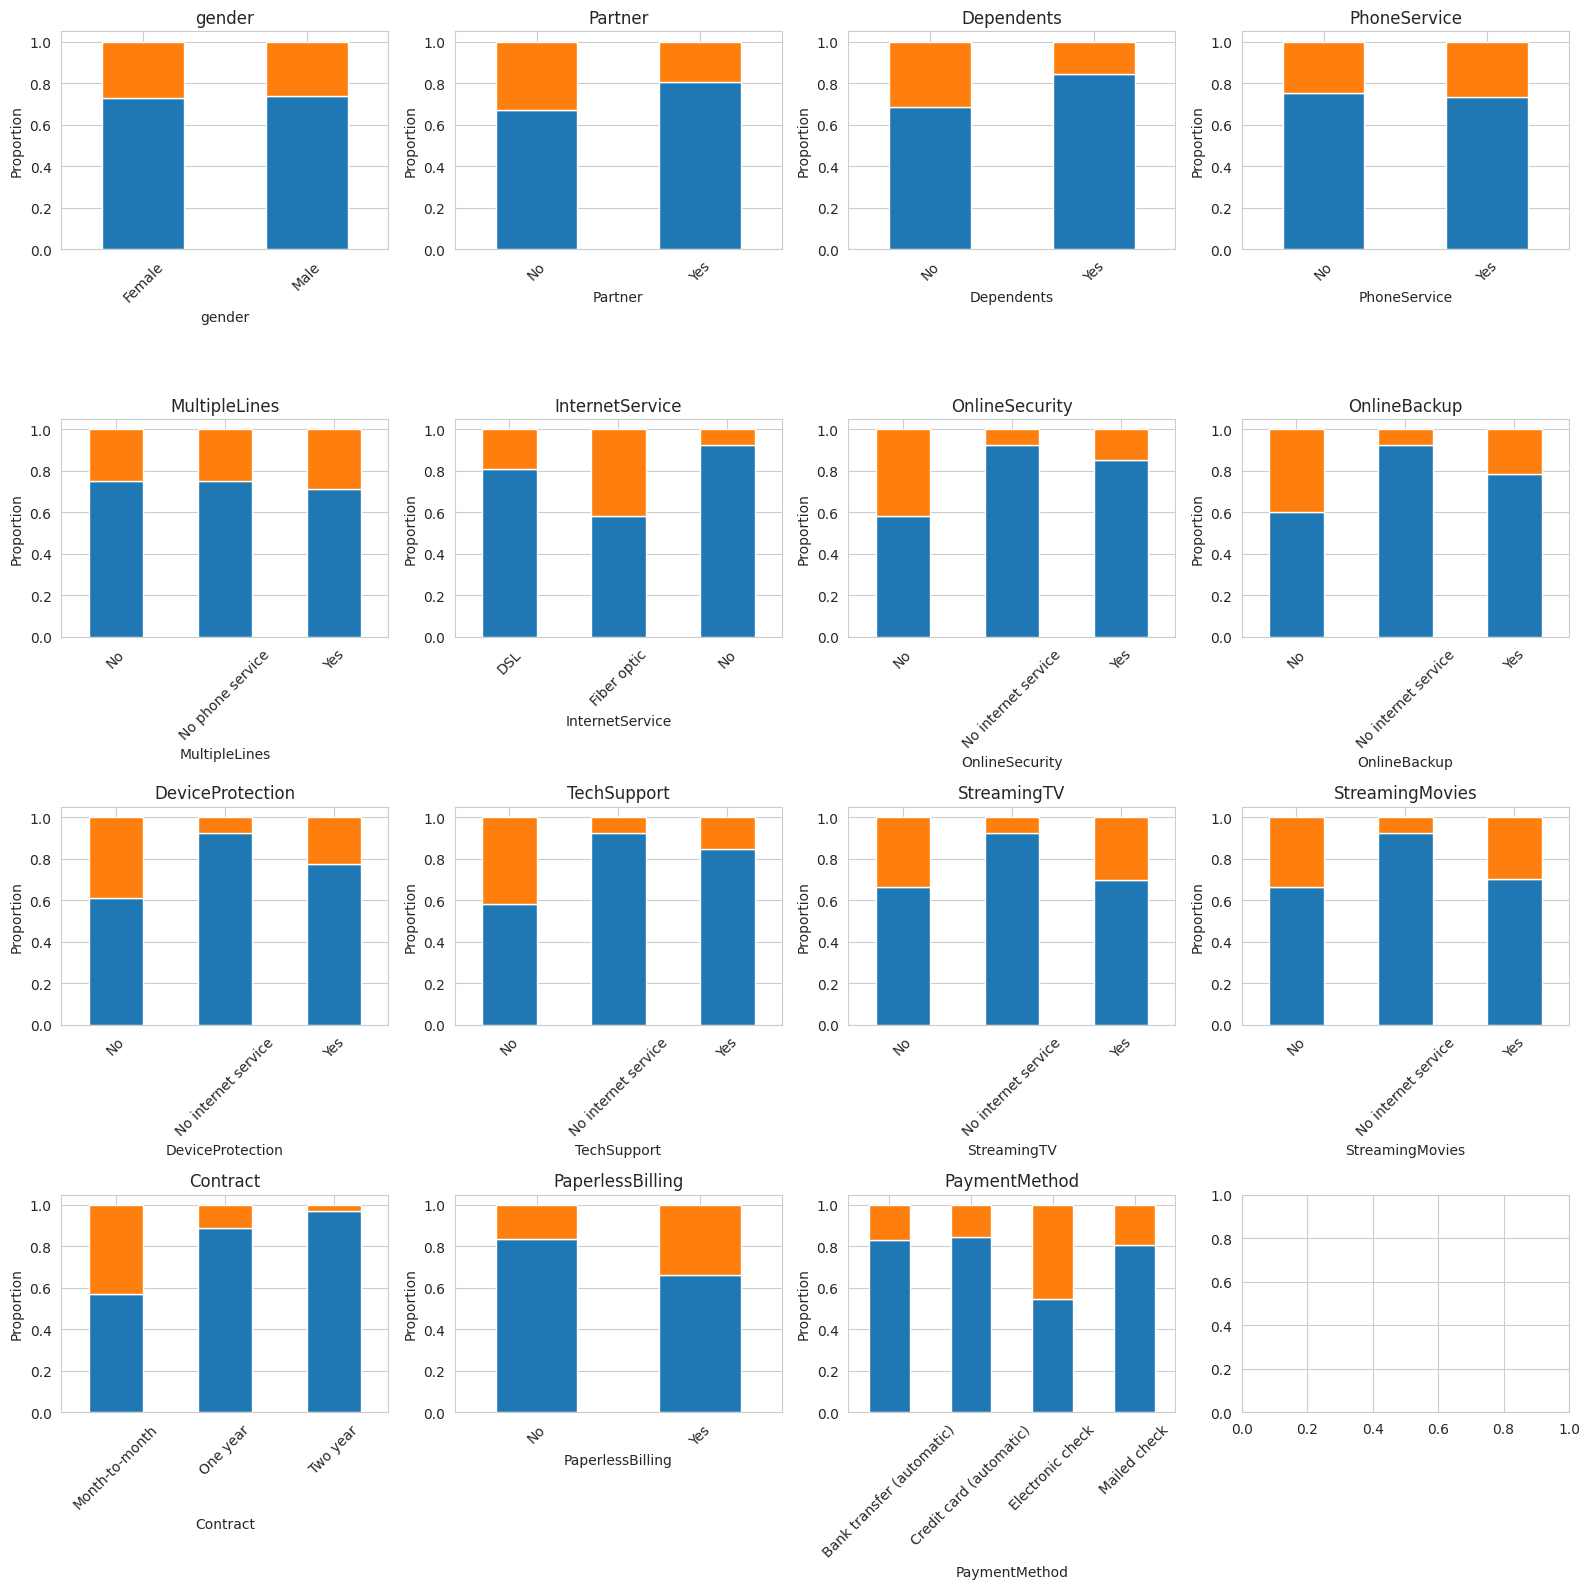

In [ ]:
categorical_features = df.select_dtypes(include=['object']).columns.drop('Churn')

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()
for i, col in enumerate(categorical_features):
    pd.crosstab(df[col], df['Churn'], normalize='index').plot(kind='bar', stacked=True, ax=axes[i], legend=False)
    axes[i].set_title(col)
    axes[i].set_ylabel('Proportion')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Correlation Heatmap (Numerical)

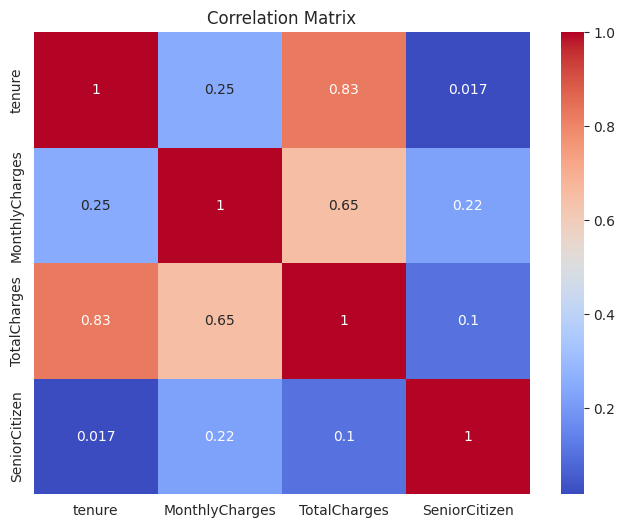

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df[numerical_features + ['SeniorCitizen']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

Feature Engineering & Encoding

In [ ]:
# List of binary categorical features (including those with "No X service")
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

# Features that have "No internet service" or "No phone service"
service_cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in service_cols:
    df[col] = df[col].replace({'No internet service': 'No', 'No phone service': 'No'})

binary_cols.extend(service_cols)

le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

df['Churn'] = le.fit_transform(df['Churn'])   # Yes=1, No=0

multi_cat_cols = ['InternetService', 'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)   # drop_first to avoid multicollinearity



print(f"Final shape: {df.shape}")
df.head()

Final shape: (7043, 24)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,False,False,True,False,False,False,True
2,1,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,False,False,True,False,False,False,False
4,0,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,True,False,False,False,False,True,False


Feature Selection

In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']

# Mutual information feature selection
selector = SelectKBest(score_func=mutual_info_classif, k=20)   # we select 20 best features
X_selected = selector.fit_transform(X, y)

# Get the names
selected_mask = selector.get_support()
selected_features = X.columns[selected_mask]
print(f"Selected {len(selected_features)} features:\n", selected_features.tolist())

# Update X to only selected features
X = X[selected_features]

Selected 20 features:
 ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'OnlineSecurity', 'OnlineBackup', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


Train/Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

Training set size: (5634, 20)
Test set size: (1409, 20)


Standardization (for models sensitive to scale)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Model Definitions & Hyperparameter Tuning

  We define dictionaries for each model:




*    model – the estimator (with random_state for reproducibility)

*  param_grid – hyperparameters to search


*  scaled – whether the model requires scaled data










In [ ]:
models = [
    {
        'name': 'Logistic Regression',
        'model': LogisticRegression(random_state=42, max_iter=1000),
        'param_grid': {'C': [0.01, 0.1, 1, 10]},
        'scaled': True
    },
    {
        'name': 'Naive Bayes',
        'model': GaussianNB(),
        'param_grid': {'var_smoothing': [1e-9, 1e-8, 1e-7]},
        'scaled': False
    },
    {
        'name': 'SVM Linear',
        'model': SVC(kernel='linear', random_state=42, probability=True),   # probability=True for AUC
        'param_grid': {'C': [0.1, 1, 10]},
        'scaled': True
    },
    {
        'name': 'SVM Poly',
        'model': SVC(kernel='poly', random_state=42, probability=True),
        'param_grid': {'C': [0.1, 1, 10], 'degree': [2, 3]},
        'scaled': True
    },
    {
        'name': 'Decision Tree',
        'model': DecisionTreeClassifier(random_state=42),
        'param_grid': {'max_depth': [3, 5, 7, 10, None], 'min_samples_split': [2, 5, 10]},
        'scaled': False
    },
    {
        'name': 'Random Forest',
        'model': RandomForestClassifier(random_state=42),
        'param_grid': {'n_estimators': [100, 200], 'max_depth': [5, 10, None], 'min_samples_split': [2, 5]},
        'scaled': False
    },
    {
        'name': 'Extra Trees',
        'model': ExtraTreesClassifier(random_state=42),
        'param_grid': {'n_estimators': [100, 200], 'max_depth': [5, 10, None], 'min_samples_split': [2, 5]},
        'scaled': False
    },
    {
        'name': 'AdaBoost (DT)',
        'model': AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), random_state=42),
        'param_grid': {'n_estimators': [50, 100, 200], 'learning_rate': [0.5, 1.0, 1.5]},
        'scaled': False
    },
    {
        'name': 'AdaBoost (Extra Trees)',
        'model': AdaBoostClassifier(estimator=ExtraTreesClassifier(n_estimators=10, max_depth=3, random_state=42), random_state=42),
        'param_grid': {'n_estimators': [50, 100], 'learning_rate': [0.5, 1.0]},
        'scaled': False
    },
    {
        'name': 'Random Forest + AdaBoost',
        'model': AdaBoostClassifier(estimator=RandomForestClassifier(n_estimators=50, max_depth=3, random_state=42), random_state=42),
        'param_grid': {'n_estimators': [50, 100], 'learning_rate': [0.5, 1.0]},
        'scaled': False
    },
    {
        'name': 'XGBoost',
        'model': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
        'param_grid': {'n_estimators': [100, 200], 'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.1, 0.2]},
        'scaled': False
    },
    {
        'name': 'CatBoost',
        'model': CatBoostClassifier(random_state=42, verbose=0, thread_count=2),
        'param_grid': {'iterations': [100, 200], 'depth': [4, 6], 'learning_rate': [0.03, 0.1]},
        'scaled': False
    }
]

Now we run the tuning and evaluation loop:



In [ ]:
results = []

for m in models:
    print(f"\n========== Training {m['name']} ==========")

    # Select appropriate data (scaled or original)
    if m['scaled']:
        X_tr = X_train_scaled
        X_te = X_test_scaled
    else:
        X_tr = X_train
        X_te = X_test

    # Grid search with 5-fold CV
    grid = GridSearchCV(m['model'], m['param_grid'], cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)
    grid.fit(X_tr, y_train)

    best_model = grid.best_estimator_
    print(f"Best params: {grid.best_params_}")
    print(f"Best CV AUC: {grid.best_score_:.4f}")

    # Predictions on test set
    y_pred = best_model.predict(X_te)
    y_proba = best_model.predict_proba(X_te)[:, 1]   # probability of positive class (churn)

    # Compute metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    # Store results
    results.append({
        'Model': m['name'],
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1,
        'AUC': auc,
        'Best Params': grid.best_params_
    })

    # Optional: print confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"Confusion Matrix:\n{cm}")
    print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")


========== Training Logistic Regression ==========
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best params: {'C': 10}
Best CV AUC: 0.8448
Confusion Matrix:
[[919 116]
 [174 200]]
Accuracy: 0.7942, Precision: 0.6329, Recall: 0.5348, F1: 0.5797, AUC: 0.8414

========== Training Naive Bayes ==========
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best params: {'var_smoothing': 1e-08}
Best CV AUC: 0.8334
Confusion Matrix:
[[764 271]
 [ 93 281]]
Accuracy: 0.7417, Precision: 0.5091, Recall: 0.7513, F1: 0.6069, AUC: 0.8267

========== Training SVM Linear ==========
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best params: {'C': 0.1}
Best CV AUC: 0.8323
Confusion Matrix:
[[912 123]
 [179 195]]
Accuracy: 0.7857, Precision: 0.6132, Recall: 0.5214, F1: 0.5636, AUC: 0.8244

========== Training SVM Poly ==========
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'C': 0.1, 'degree': 3}
Best CV AUC: 0.8269
Confusion Matrix:
[[989 

Results Compilation and Comparison

In [ ]:
# Create DataFrame with results
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('AUC', ascending=False).reset_index(drop=True)

# Display results
print("\n========== Model Performance Comparison ==========")
print(results_df.to_string(index=False))

# Save to CSV for later reference
results_df.to_csv('churn_prediction_results.csv', index=False)


========== Model Performance Comparison ==========
                   Model  Accuracy  Precision   Recall  F1-score      AUC                                                    Best Params
                CatBoost  0.798439   0.658451 0.500000  0.568389 0.847136         {'depth': 4, 'iterations': 200, 'learning_rate': 0.03}
                 XGBoost  0.797019   0.650685 0.508021  0.570571 0.844193    {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
           Random Forest  0.789212   0.666667 0.411765  0.509091 0.842442  {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}
     Logistic Regression  0.794180   0.632911 0.534759  0.579710 0.841352                                                      {'C': 10}
             Extra Trees  0.801987   0.658863 0.526738  0.585438 0.841310 {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
           AdaBoost (DT)  0.799148   0.657439 0.508021  0.573152 0.840785                    {'learning_rate': 0.5, 'n_estimat

Visualizing ROC Curves

ROC for Logistic Regression
ROC for Naive Bayes
ROC for SVM Linear
ROC for SVM Poly
ROC for Decision Tree
ROC for Random Forest
ROC for Extra Trees
ROC for AdaBoost (DT)
ROC for AdaBoost (Extra Trees)
ROC for Random Forest + AdaBoost
ROC for XGBoost
ROC for CatBoost


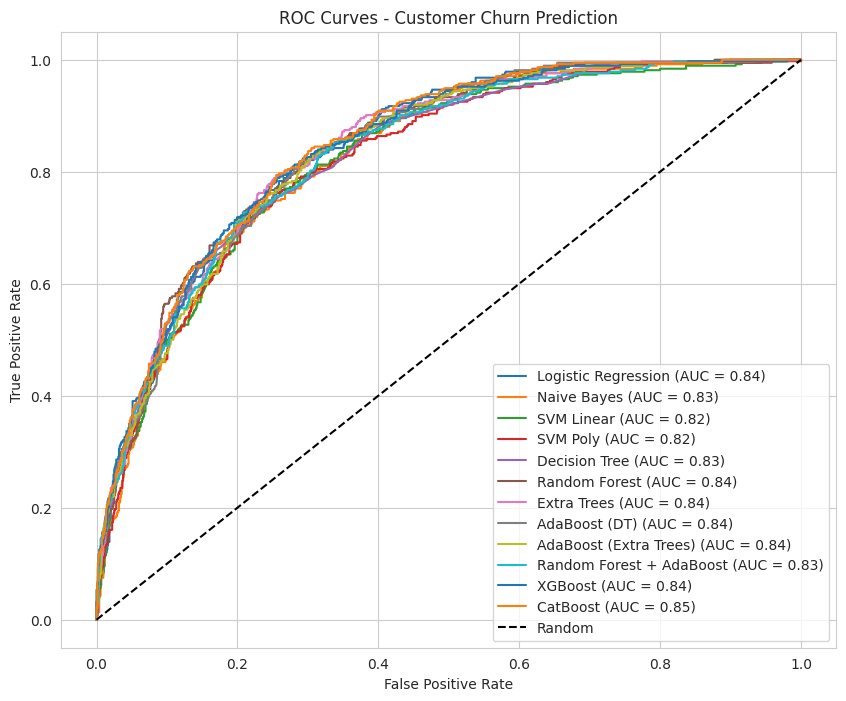

In [ ]:
plt.figure(figsize=(10, 8))

best_models = {}

for m in models:
    print(f"ROC for {m['name']}")
    if m['scaled']:
        X_tr = X_train_scaled
        X_te = X_test_scaled
    else:
        X_tr = X_train
        X_te = X_test
    # Changed n_jobs to 1 to avoid potential multiprocessing issues or resource exhaustion
    grid = GridSearchCV(m['model'], m['param_grid'], cv=5, scoring='roc_auc', n_jobs=1, verbose=0)
    grid.fit(X_tr, y_train)
    best_models[m['name']] = grid.best_estimator_
    y_proba = grid.best_estimator_.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{m['name']} (AUC = {auc_score:.2f})")

plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Customer Churn Prediction')
plt.legend(loc='lower right')
plt.show()